# Clustering: DBSCAN e Hierarchical Clustering

In questa lezione esploriamo **DBSCAN** e **Hierarchical Clustering**, due algoritmi che superano alcune limitazioni di K-Means.

---
## 1. Setup e Importazioni

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


plt.style.use('seaborn-v0_8-whitegrid')

---
## 2. Ripasso: I Limiti di K-Means

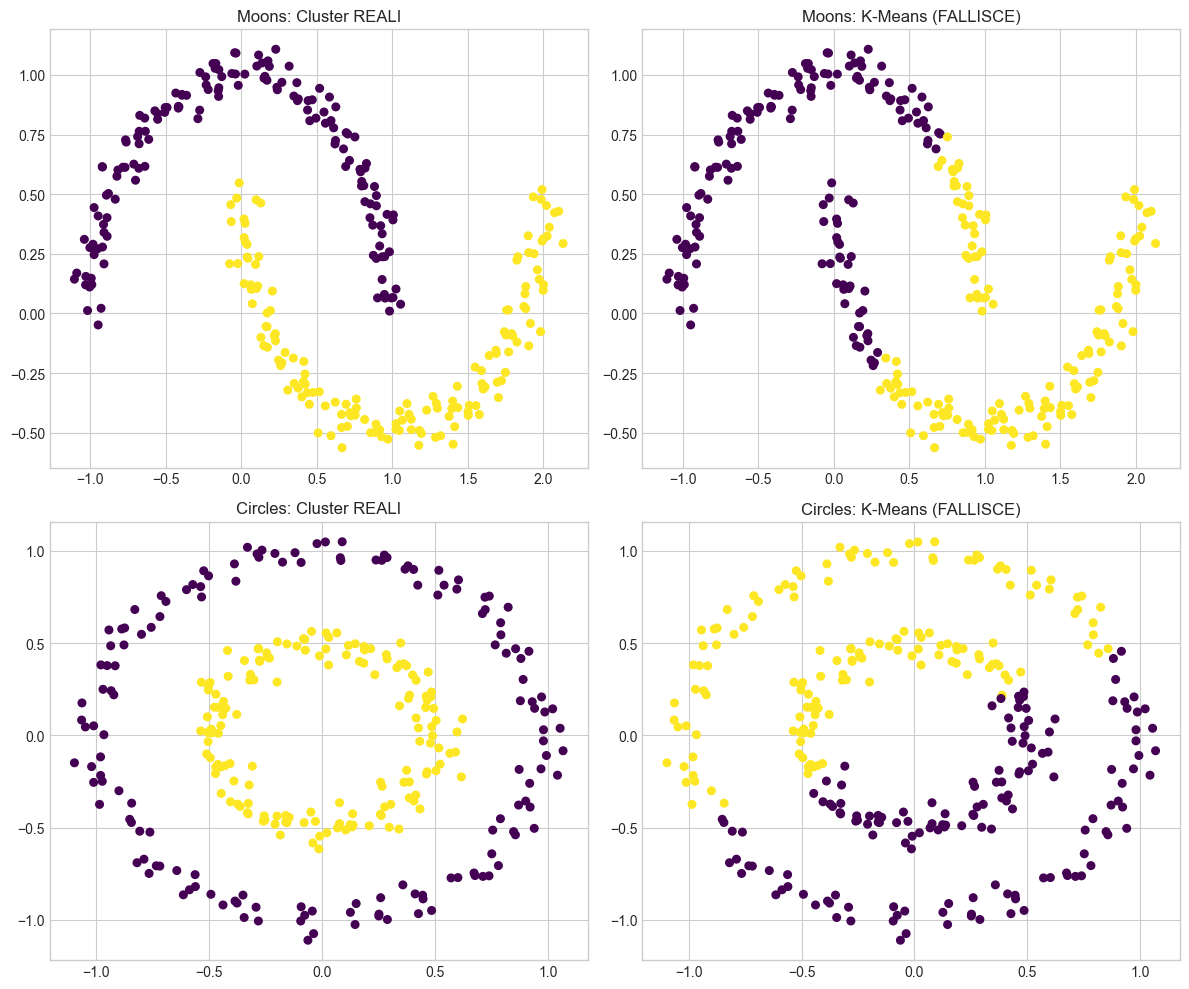

In [6]:
np.random.seed(42)

X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, 
                                    random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Moons                  x            y
axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=30)
axes[0, 0].set_title('Moons: Cluster REALI')

kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons)
axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans_moons, cmap='viridis', s=30)
axes[0, 1].set_title('Moons: K-Means (FALLISCE)')

# Circles
axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', s=30)
axes[1, 0].set_title('Circles: Cluster REALI')

kmeans_circles = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_circles = kmeans_circles.fit_predict(X_circles)
axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_kmeans_circles, cmap='viridis', s=30)
axes[1, 1].set_title('Circles: K-Means (FALLISCE)')

plt.tight_layout()
plt.show()

---
## 3. DBSCAN: Density-Based Spatial Clustering

### 3.1 Idea Chiave

DBSCAN definisce i cluster come **regioni dense** separate da **regioni sparse**.

**Parametri:**
- **eps (ε):** Raggio del vicinato
- **min_samples:** Punti minimi per definire una regione densa

DBSCAN guarda ogni punto e conta quanti altri punti (min_samples) ha nel suo vicinato (entro il raggio eps).


**Tipi di punti:**
- **Core point:** Ha almeno `min_samples` punti nel suo vicinato ε
- **Border point:** Non è core, ma è vicino a un core point
- **Noise point:** Né core né border → etichetta = -1

Ad esempio, supponendo min_samples=5 e eps="1 casella":<br>
● ● ●<br>
● C ●&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;      C = Core Point (ha 5+ vicini)<br>
● ● B&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;      B = Border Point (ha 2 vicini, ma è vicino a C)<br>

&nbsp;&nbsp;&nbsp;&nbsp;  N&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;    N = Noise (isolato, non vicino a nessun Core)

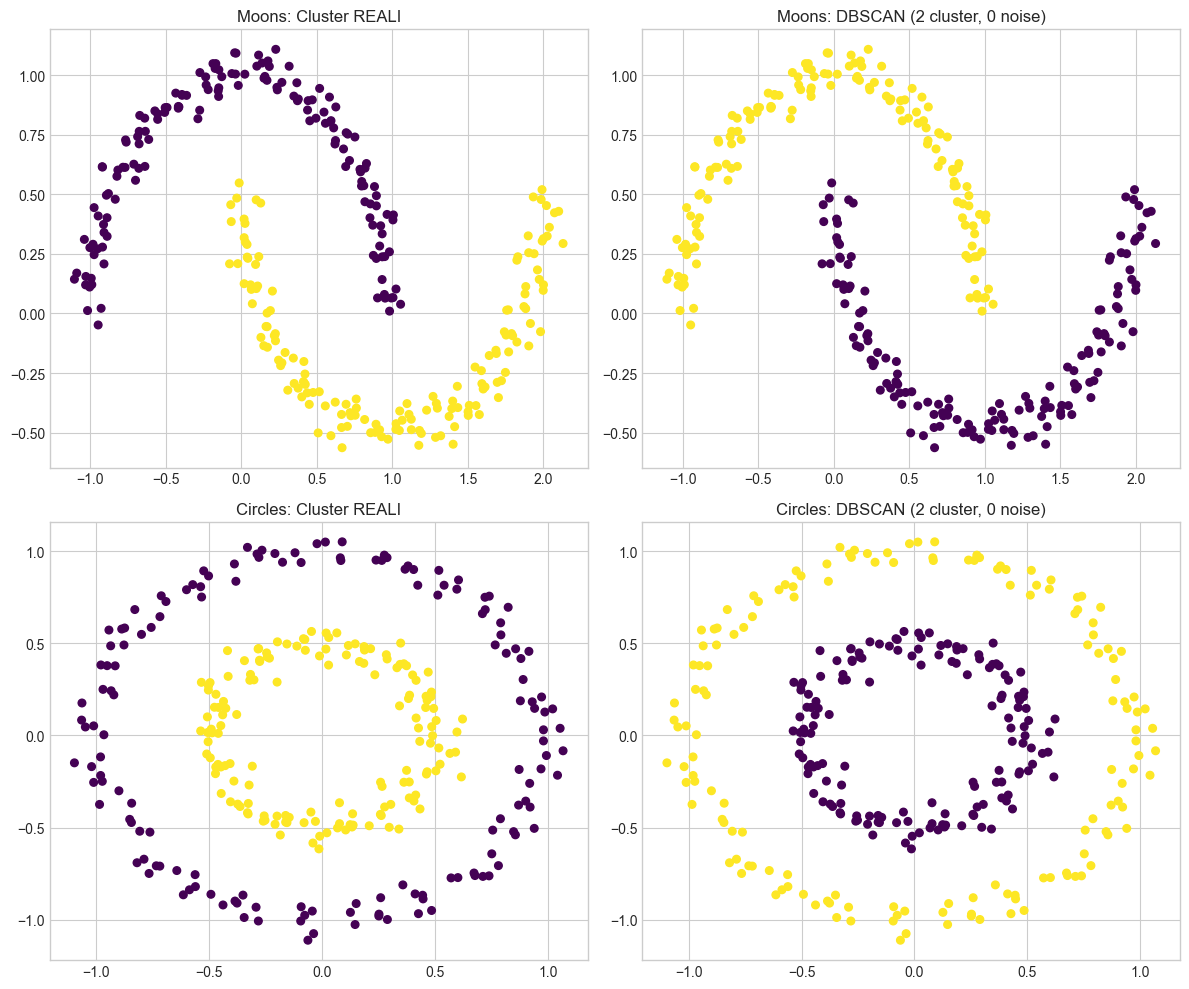

In [7]:
# DBSCAN sui dataset problematici
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Moons con DBSCAN
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons)

axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=30)
axes[0, 0].set_title('Moons: Cluster REALI')

axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan_moons, 
                   cmap='viridis', s=30)
n_clusters = len(set(labels_dbscan_moons)) - (1 if -1 in labels_dbscan_moons else 0)
n_noise = list(labels_dbscan_moons).count(-1)
axes[0, 1].set_title(f'Moons: DBSCAN ({n_clusters} cluster, {n_noise} noise)')

# Circles con DBSCAN
dbscan_circles = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan_circles = dbscan_circles.fit_predict(X_circles)

axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, 
                   cmap='viridis', s=30)
axes[1, 0].set_title('Circles: Cluster REALI')

axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], 
                   c=labels_dbscan_circles, cmap='viridis', s=30)
n_clusters = len(set(labels_dbscan_circles)) - (1 if -1 in labels_dbscan_circles else 0)
n_noise = list(labels_dbscan_circles).count(-1)
axes[1, 1].set_title(f'Circles: DBSCAN ({n_clusters} cluster, {n_noise} noise)')

plt.tight_layout()
plt.show()

### 3.2 Come Scegliere eps: k-Distance Graph

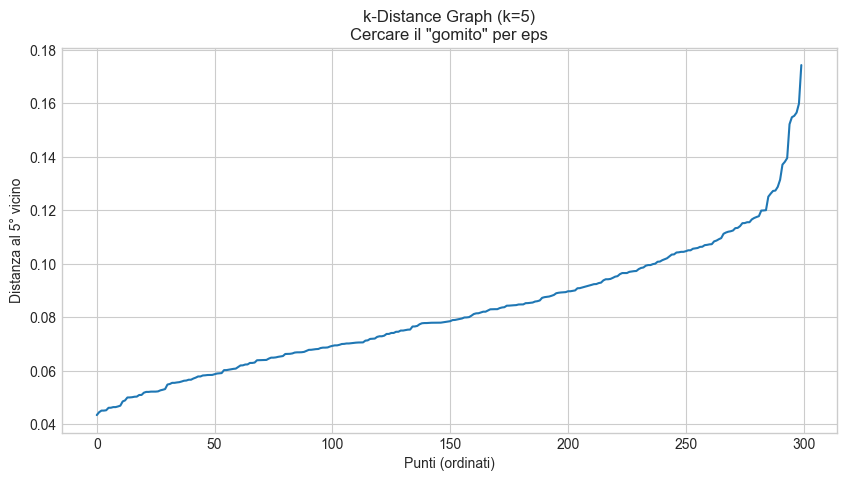

In [8]:
from numpy import indices


def plot_k_distance(X, k=5):
    """Calcola e visualizza il k-distance graph per scegliere eps."""
    #Per ogni punto in X, trova i k vicini 
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    
    # Calcola le distanze ai k vicini 
    # nbrs.kneighbors(X) ritorna due cose per ogni punto:
    # distances → le distanze ai k vicini
    # indices → gli indici di quei vicini (quali punti sono)
    # esempio: distances = [
    # [0.0, 0.02, 0.05, 0.08, 0.12],  # Punto 0: distanze ai suoi 5 vicini
    # [0.0, 0.03, 0.04, 0.09, 0.15],  # Punto 1: distanze ai suoi 5 vicini
    # [0.0, 0.01, 0.06, 0.07, 0.10],  # Punto 2: distanze ai suoi 5 vicini
    # ... ]
    # indices = [
    # [0, 5, 12, 8, 3],   # Punto 0: i suoi vicini sono i punti 0, 5, 12, 8, 3
    # [1, 7, 2, 15, 9],   # Punto 1: i suoi vicini sono i punti 1, 7, 2, 15, 9
    # [2, 1, 6, 11, 4],   # Punto 2: i suoi vicini sono i punti 2, 1, 6, 11, 4
    # ... ] 
    distances, _ = nbrs.kneighbors(X)
    
    # perchè [:, -1]? 
    k_distances = np.sort(distances[:, -1])
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(k_distances)), k_distances)
    plt.xlabel('Punti (ordinati)')
    plt.ylabel(f'Distanza al {k}° vicino')
    plt.title(f'k-Distance Graph (k={k})\nCercare il "gomito" per eps')
    plt.grid(True)
    plt.show()

plot_k_distance(X_moons, k=5)

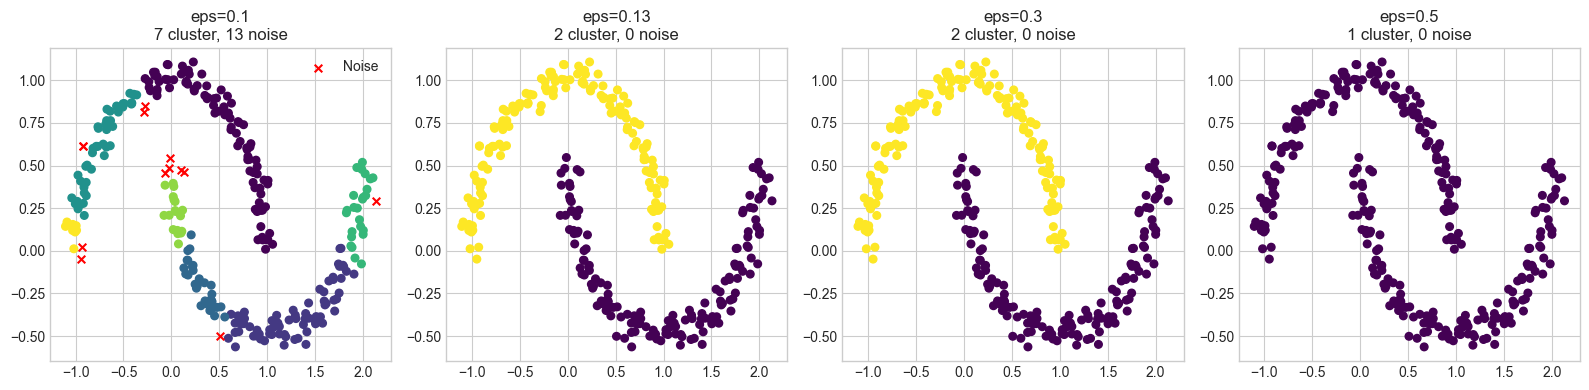

In [11]:
# Testare diversi eps
eps_values = [0.1, 0.13, 0.3, 0.5]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, eps in zip(axes, eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_moons)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    noise_mask = labels == -1
    ax.scatter(X_moons[~noise_mask, 0], X_moons[~noise_mask, 1], 
               c=labels[~noise_mask], cmap='viridis', s=30)
    ax.scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1], 
               c='red', s=30, marker='x', label='Noise')
    ax.set_title(f'eps={eps}\n{n_clusters} cluster, {n_noise} noise')
    if noise_mask.sum() > 0:
        ax.legend()

plt.tight_layout()
plt.show()

### 3.3 DBSCAN e Outlier

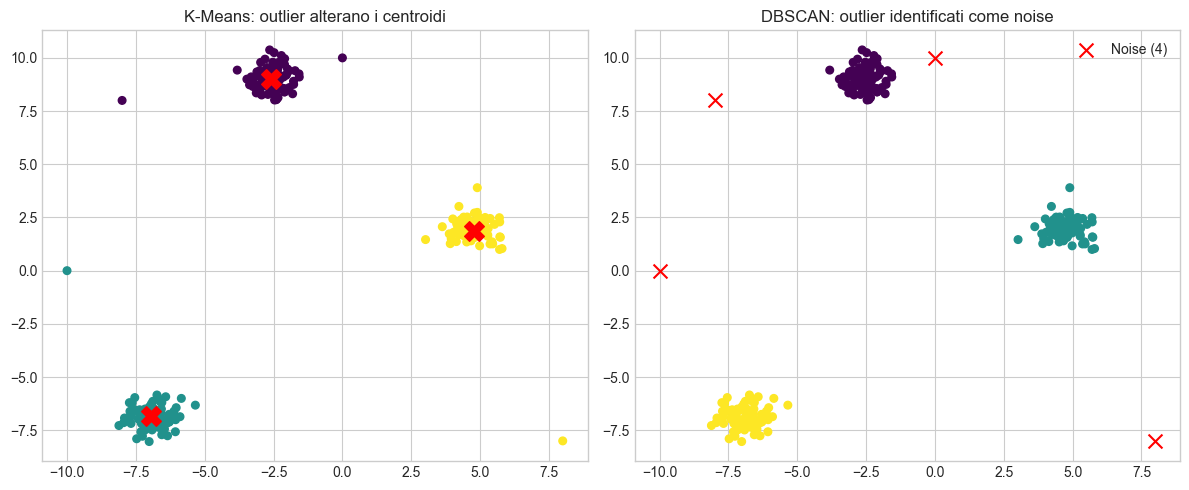

In [12]:
# Dataset con outlier
X_outliers, _ = make_blobs(n_samples=280, centers=3, cluster_std=0.5, 
                           random_state=42)
outliers = np.array([[-8, 8], [8, -8], [0, 10], [-10, 0]])
X_outliers = np.vstack([X_outliers, outliers])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_outliers)
axes[0].scatter(X_outliers[:, 0], X_outliers[:, 1], c=labels_km, cmap='viridis', s=30)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200)
axes[0].set_title('K-Means: outlier alterano i centroidi')

# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
labels_db = dbscan.fit_predict(X_outliers)
noise_mask = labels_db == -1
axes[1].scatter(X_outliers[~noise_mask, 0], X_outliers[~noise_mask, 1], 
                c=labels_db[~noise_mask], cmap='viridis', s=30)
axes[1].scatter(X_outliers[noise_mask, 0], X_outliers[noise_mask, 1], 
                c='red', s=100, marker='x', label=f'Noise ({noise_mask.sum()})')
axes[1].set_title('DBSCAN: outlier identificati come noise')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Hierarchical Clustering

### 4.1 Idea Chiave

Costruisce una **gerarchia di cluster** visualizzabile come **dendrogramma**.

**Approccio agglomerativo (bottom-up):**
1. Ogni punto è un cluster singolo
2. Unisci iterativamente i cluster più vicini
3. Continua fino a un unico cluster

### 4.2 Tipi di Linkage

Nel clustering gerarchico, ad ogni passo bisogna decidere quali due cluster unire. Per farlo, si utilizza la "distanza" tra cluster. Il linkage definisce come calcolarla.


| Linkage | Come calcola la distanza tra cluster | Risultato |
|---------|--------------------------------------|-----------|
| **single** | Distanza euclidea minima tra qualsiasi coppia di punti nei due cluster| Tende a creare cluster "a catena" (allungati) |
| **complete** | Distanza euclidea massima tra tra qualsiasi coppia di punti nei due cluster | Tende a creare cluster compatti e sferici. |
| **average** | Distanza euclidea media tra punti dei punti nei cluster | Compromesso tra single e complete. |
| **ward** | Minimizza aumento varianza intra-cluster | Cluster compatti e bilanciati (spesso il migliore per cluster sferici). |

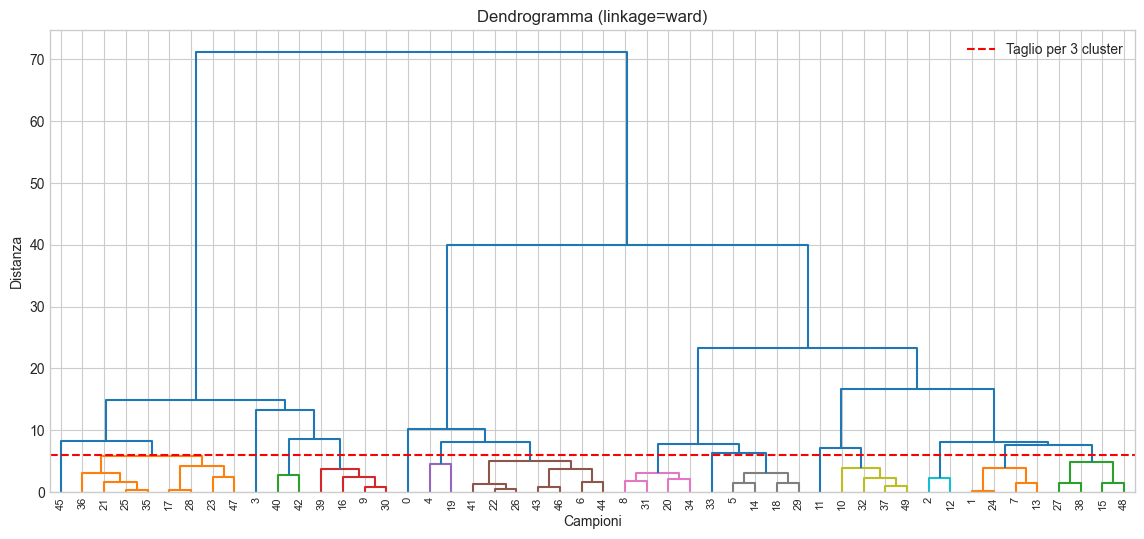

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogramma
X_hier, _ = make_blobs(n_samples=50, centers=3, cluster_std=3.8, random_state=42)

Z = linkage(X_hier, method='ward')

plt.figure(figsize=(14, 6))

# truncate_mode='level' mostra solo i primi livelli. Il parametro p indica quanti livelli mostrare
dendrogram(Z, truncate_mode='none', p=5, color_threshold=6)
plt.xlabel('Campioni')
plt.ylabel('Distanza')
plt.title('Dendrogramma (linkage=ward)')
plt.axhline(y=6, color='r', linestyle='--', label='Taglio per 3 cluster')
plt.legend()
plt.show()

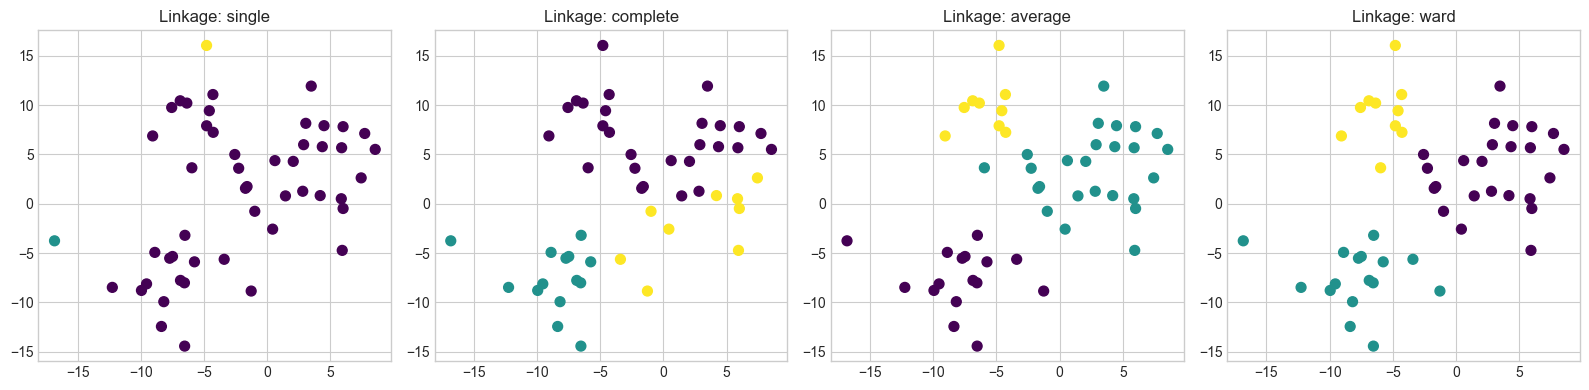

In [19]:
# Confronto linkage
linkages = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, link in zip(axes, linkages):
    agglo = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agglo.fit_predict(X_hier)
    ax.scatter(X_hier[:, 0], X_hier[:, 1], c=labels, cmap='viridis', s=50)
    ax.set_title(f'Linkage: {link}')

plt.tight_layout()
plt.show()

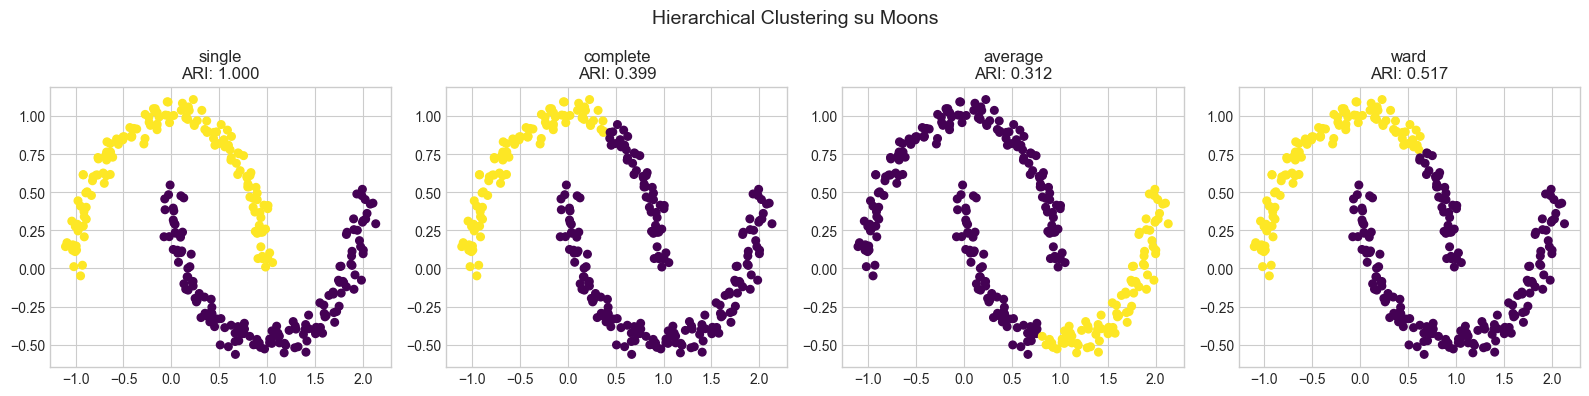

In [20]:
# Hierarchical su Moons
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, link in zip(axes, linkages):
    agglo = AgglomerativeClustering(n_clusters=2, linkage=link)
    labels = agglo.fit_predict(X_moons)
    ari = adjusted_rand_score(y_moons, labels)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap='viridis', s=30)
    ax.set_title(f'{link}\nARI: {ari:.3f}')

plt.suptitle('Hierarchical Clustering su Moons', fontsize=14)
plt.tight_layout()
plt.show()

**Nota:** `single` linkage funziona bene con cluster non sferici!

# ARI - Adjusted Rand Index
L'ARI misura quanto i cluster trovati corrispondono alle etichette reali.

Confronta le coppie di punti:
- Sono nello stesso cluster E nella stessa classe reale? ok
- Sono in cluster diversi E in classi diverse? ok
- Altrimenti → il clustering ha sbagliato

Valori possibili [-1.0; 1.0] <br>
1.0 Clustering perfetto (identico alle etichette reali) <br>
0.0 Clustering casuale<br>
< 0.0 Peggio del caso casuale<br>


---
## 5. Confronto Completo degli Algoritmi

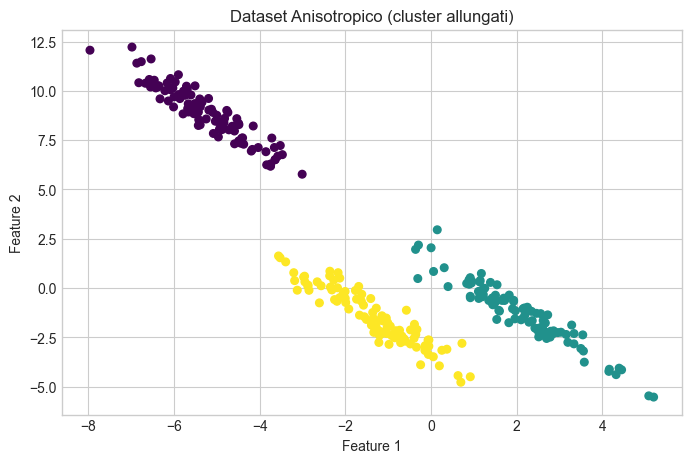

In [23]:
# Preparare dataset
datasets = {
    'Blobs': make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),
    'Moons': (X_moons, y_moons),
    'Circles': (X_circles, y_circles),
}

# Anisotropic
X_aniso, y_aniso = make_blobs(n_samples=300, centers=3, random_state=42, 
                              cluster_std=1.5)

# applichiamo una trasformazione lineare per creare cluster allungati
# Per ogni punto [x, y]:
# nuovo_x = 0.6*x + (-0.4)*y    ← prima riga
# nuovo_y = -0.6*x + 0.8*y      ← seconda riga
X_aniso = np.dot(X_aniso, [[0.6, -0.6], 
                           [-0.4, 0.8]])
datasets['Anisotropic'] = (X_aniso, y_aniso)


plt.figure(figsize=(8, 5))
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_aniso, cmap='viridis', s=30)
plt.title('Dataset Anisotropico (cluster allungati)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


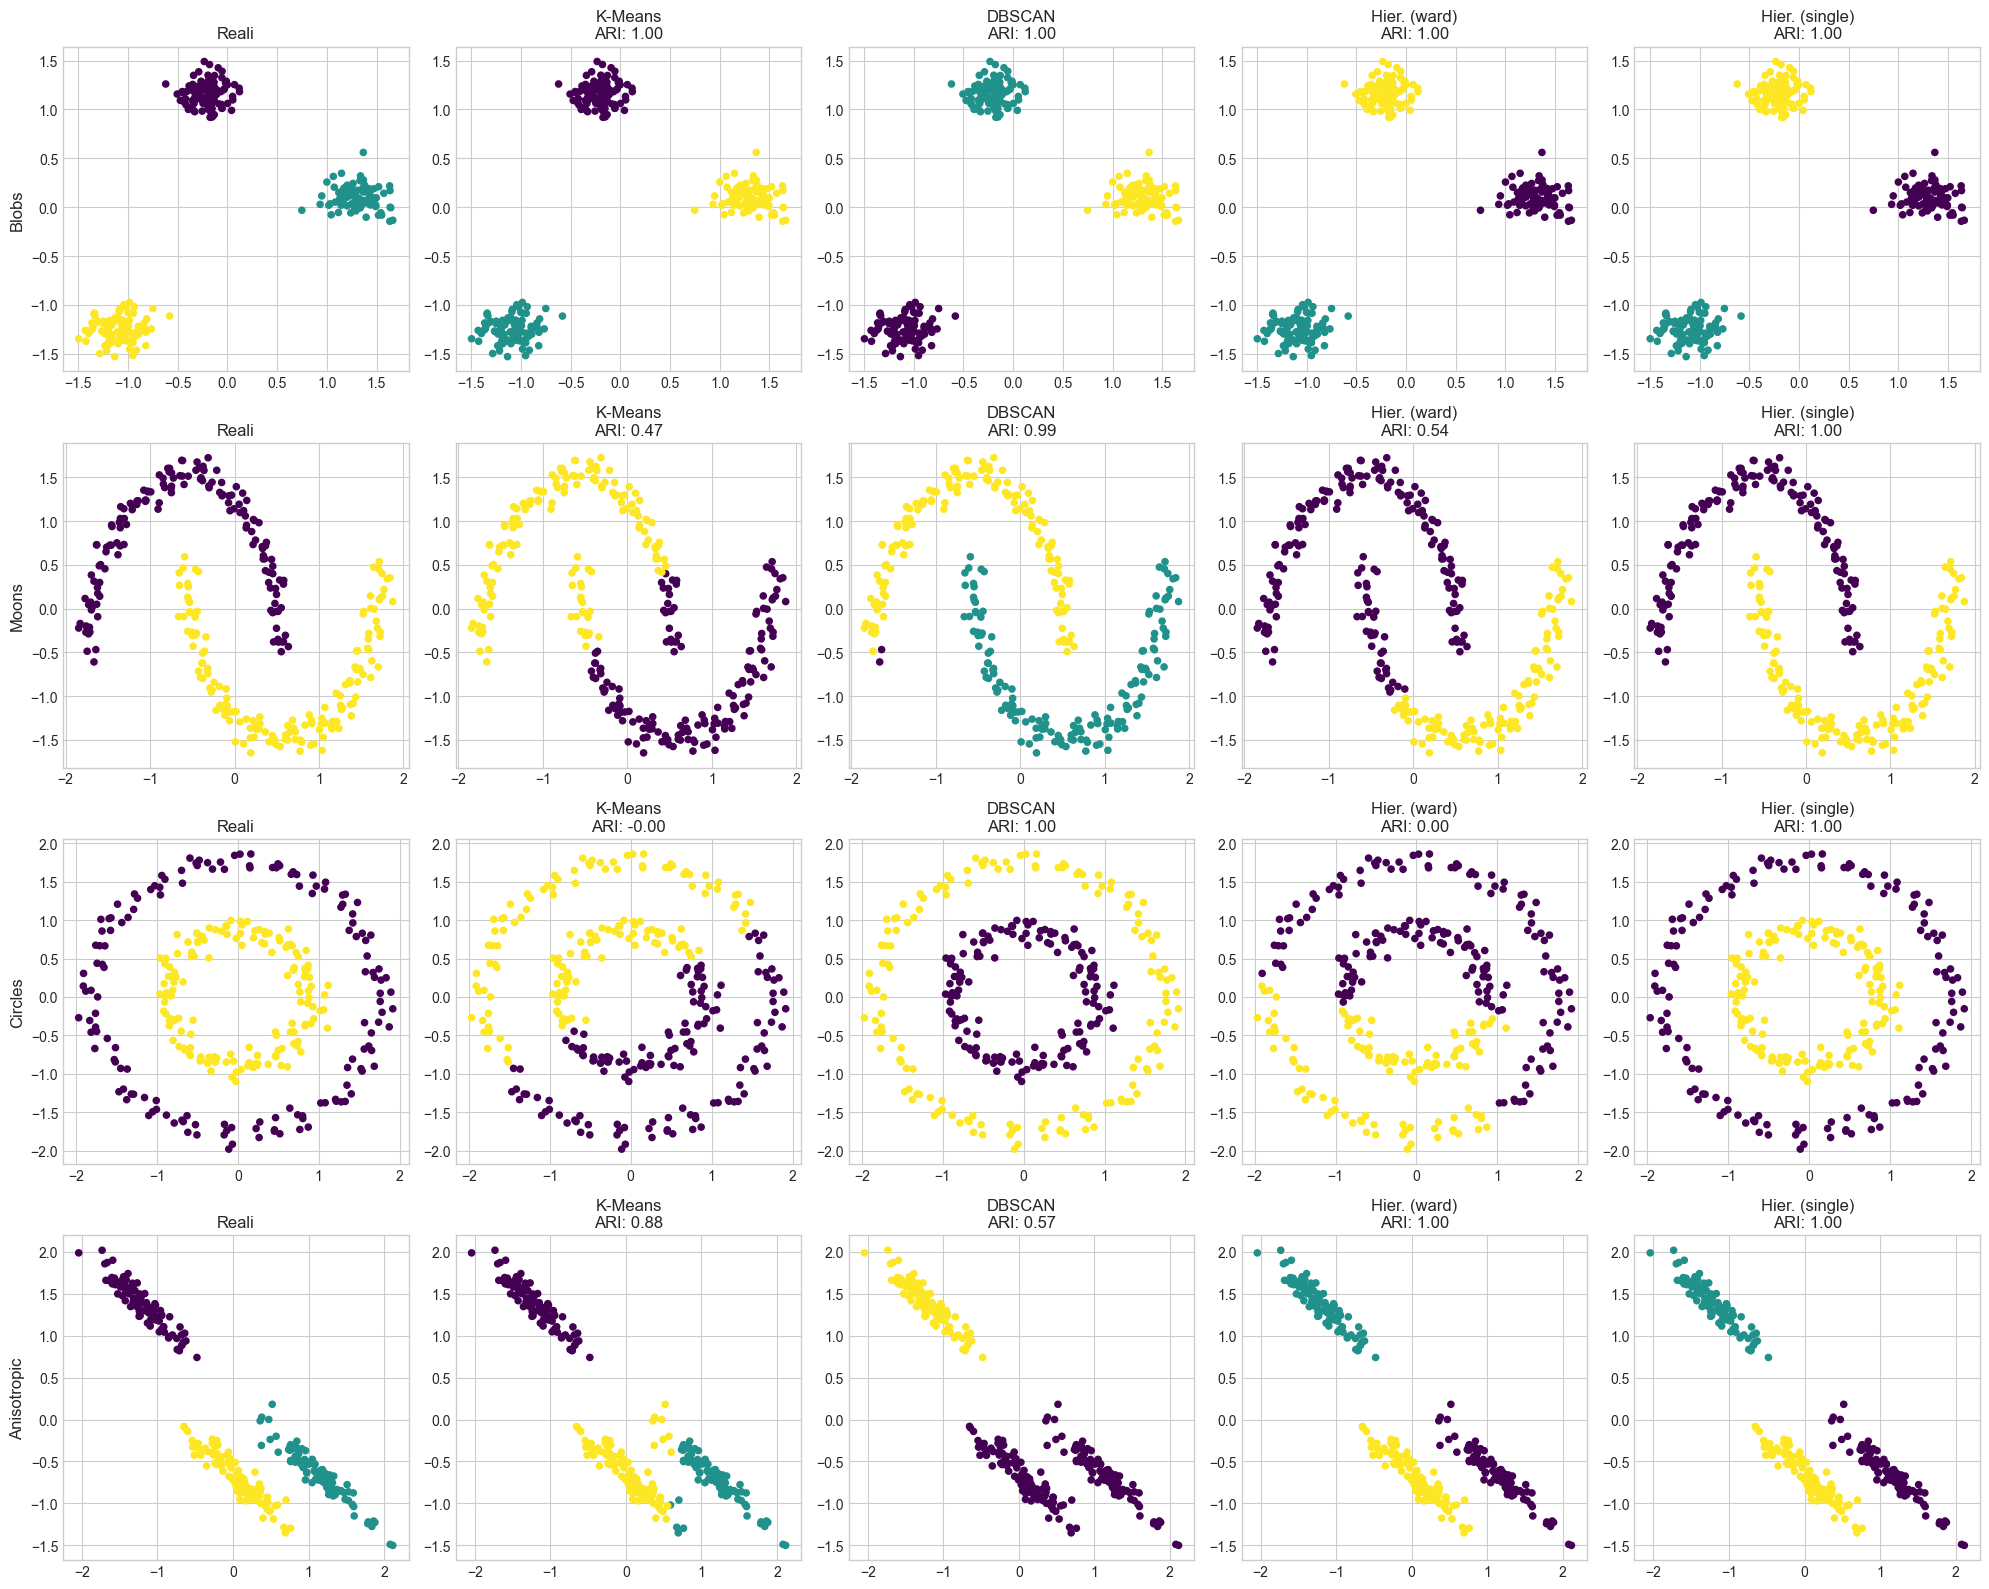

In [24]:
# Confronto visivo
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

eps_per_dataset = {'Blobs': 0.5, 'Moons': 0.2, 'Circles': 0.35, 
                   'Anisotropic': 0.4}


for i, (ds_name, (X, y)) in enumerate(datasets.items()):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Dati originali
    axes[i, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', s=20)
    axes[i, 0].set_title('Reali')
    axes[i, 0].set_ylabel(ds_name, fontsize=12)
    
    # K-Means
    km = KMeans(n_clusters=len(np.unique(y)), random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    axes[i, 1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km, cmap='viridis', s=20)
    axes[i, 1].set_title(f'K-Means\nARI: {adjusted_rand_score(y, labels_km):.2f}')
    
    # DBSCAN
    db = DBSCAN(eps=eps_per_dataset[ds_name], min_samples=5)
    labels_db = db.fit_predict(X_scaled)
    axes[i, 2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, cmap='viridis', s=20)
    axes[i, 2].set_title(f'DBSCAN\nARI: {adjusted_rand_score(y, labels_db):.2f}')
    
    # Hierarchical Ward
    hw = AgglomerativeClustering(n_clusters=len(np.unique(y)), linkage='ward')
    labels_hw = hw.fit_predict(X_scaled)
    axes[i, 3].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_hw, cmap='viridis', s=20)
    axes[i, 3].set_title(f'Hier. (ward)\nARI: {adjusted_rand_score(y, labels_hw):.2f}')
    
    # Hierarchical Single
    hs = AgglomerativeClustering(n_clusters=len(np.unique(y)), linkage='single')
    labels_hs = hs.fit_predict(X_scaled)
    axes[i, 4].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_hs, cmap='viridis', s=20)
    axes[i, 4].set_title(f'Hier. (single)\nARI: {adjusted_rand_score(y, labels_hs):.2f}')

plt.tight_layout()
plt.show()

---
## 6. Caso Pratico: Dataset Iris

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

results = []

algorithms = {
    'K-Means': KMeans(n_clusters=3, random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Hier. (Ward)': AgglomerativeClustering(n_clusters=3, linkage='ward'),
    'Hier. (Single)': AgglomerativeClustering(n_clusters=3, linkage='single')
}

for name, alg in algorithms.items():
    labels = alg.fit_predict(X_iris_scaled)
    ari = adjusted_rand_score(y_iris, labels)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Silhouette
    if n_clusters >= 2:
        if -1 in labels:
            mask = labels != -1
            sil = silhouette_score(X_iris_scaled[mask], labels[mask])
        else:
            sil = silhouette_score(X_iris_scaled, labels)
    else:
        sil = np.nan
    
    results.append({
        'Algoritmo': name,
        'N. Cluster': n_clusters,
        'N. Noise': n_noise,
        'ARI': round(ari, 3),
        'Silhouette': round(sil, 3) if not np.isnan(sil) else 'N/A'
    })

print("Confronto algoritmi su Iris:")
pd.DataFrame(results)

Confronto algoritmi su Iris:


,Algoritmo,N. Cluster,N. Noise,ARI,Silhouette
0,K-Means,3,0,0.620,0.460
1,DBSCAN,2,34,0.442,0.656
2,Hier. (Ward),3,0,0.615,0.447
3,Hier. (Single),3,0,0.558,0.505


---
## 7. Tabella Riepilogativa

| Caratteristica | K-Means | DBSCAN | Hierarchical |
|----------------|---------|--------|-------------|
| **Richiede K** | Sì | No | Sì |
| **Forma cluster** | Sferici | Arbitraria | Dipende da linkage |
| **Gestisce outlier** | No | Sì (noise) | No |
| **Quando usarlo** | Cluster sferici, grandi dataset | Forme arbitrarie, outlier | Dendrogramma utile |

---
## 8. Esercizi

### Esercizio 1: Tuning DBSCAN

Genera un dataset con `make_moons(n_samples=500, noise=0.1)`:
1. Usa il k-distance graph per trovare eps ottimale
2. Testa min_samples = 3, 5, 10, 20
3. Qual è la combinazione migliore (usa ARI)?

In [ ]:
# Il tuo codice qui


### Esercizio 2: Clustering su Breast Cancer

Carica il dataset Breast Cancer (`load_breast_cancer`):
1. Standardizza i dati
2. Applica K-Means e Hierarchical (Ward) con n_clusters=2
3. Calcola ARI e Silhouette per ogni algoritmo
4. Confronta i cluster trovati con le diagnosi reali usando pd.crosstab



In [ ]:
# Il tuo codice qui


---
## Soluzioni

### Soluzione Esercizio 1

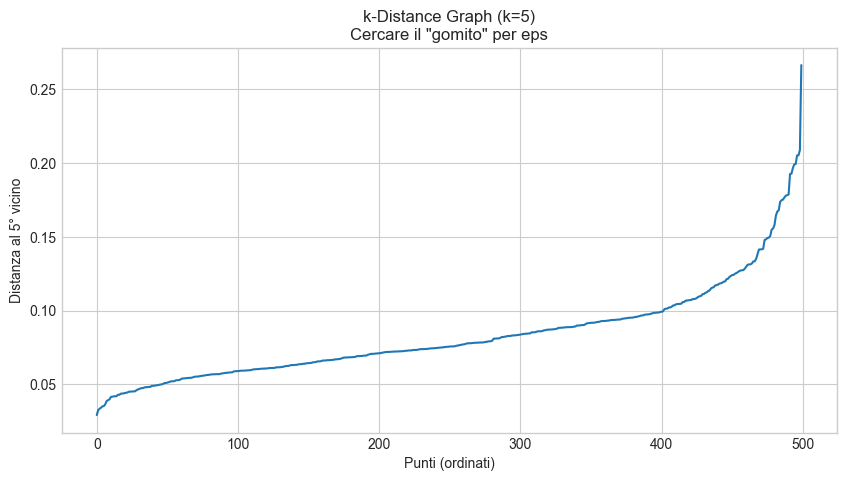

     eps  min_samples  n_clusters  n_noise    ARI
12  0.25            3           2        0  1.000
8   0.20            3           2        0  1.000
10  0.20           10           2        0  1.000
9   0.20            5           2        0  1.000
15  0.25           20           2        0  1.000
14  0.25           10           2        0  1.000
13  0.25            5           2        0  1.000
4   0.15            3           2        2  0.992
5   0.15            5           2        2  0.992
11  0.20           20           2        9  0.964


In [26]:
X_ex1, y_ex1 = make_moons(n_samples=500, noise=0.1, random_state=42)

# k-distance graph
plot_k_distance(X_ex1, k=5)

# Grid search
eps_values = [0.1, 0.15, 0.2, 0.25, 0.3]
min_samples_values = [3, 5, 10, 20]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_ex1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        ari = adjusted_rand_score(y_ex1, labels)
        results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 
                        'n_noise': n_noise, 'ARI': round(ari, 3)})

df_results = pd.DataFrame(results)
print(df_results.sort_values('ARI', ascending=False).head(10))

### Soluzione Esercizio 2

Campioni: 569, Features: 30
Classi: ['malignant' 'benign']


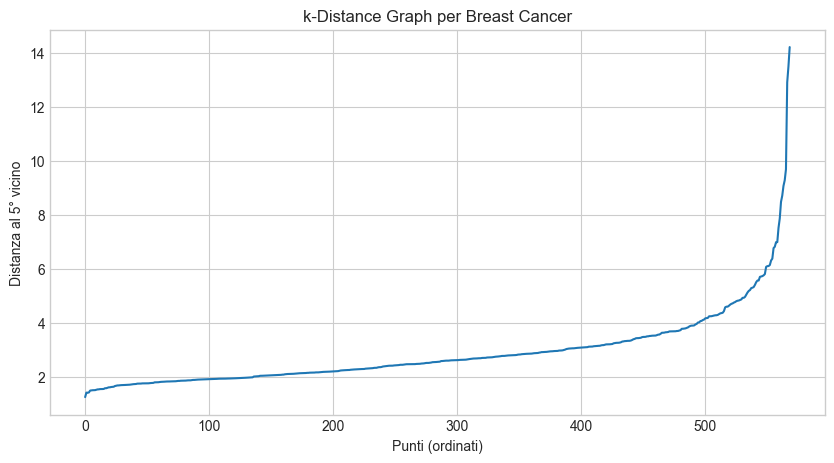

      Algoritmo  N. Cluster    ARI  Silhouette
0       K-Means           2  0.654       0.343
1        DBSCAN           2  0.120       0.436
2  Hier. (Ward)           2  0.575       0.339


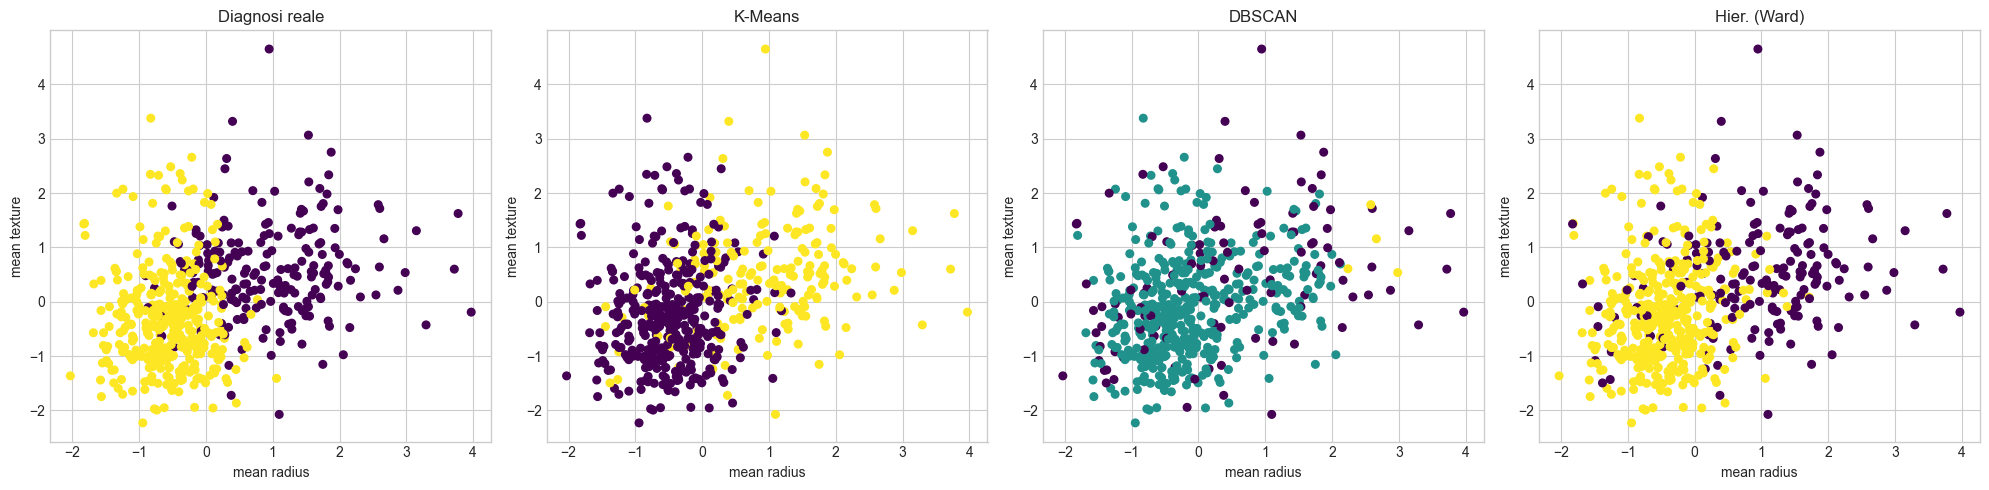


Tabella di contingenza K-Means vs Diagnosi reale:
         malignant  benign
Cluster                   
0               36     339
1              176      18


In [8]:
from sklearn.datasets import load_breast_cancer

# 1. Caricare e standardizzare
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

print(f"Campioni: {X_cancer.shape[0]}, Features: {X_cancer.shape[1]}")
print(f"Classi: {cancer.target_names}")

scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)

# 2. Trovare eps per DBSCAN con k-distance graph
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_cancer_scaled)
distances, _ = nbrs.kneighbors(X_cancer_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(range(len(k_distances)), k_distances)
plt.xlabel('Punti (ordinati)')
plt.ylabel('Distanza al 5° vicino')
plt.title('k-Distance Graph per Breast Cancer')
plt.grid(True)
plt.show()

# 3. Applicare gli algoritmi
algorithms = {
    'K-Means': KMeans(n_clusters=2, random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=3, min_samples=3),  
    'Hier. (Ward)': AgglomerativeClustering(n_clusters=2, linkage='ward')
}

results = []
all_labels = {}

for name, alg in algorithms.items():
    labels = alg.fit_predict(X_cancer_scaled)
    all_labels[name] = labels
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ari = adjusted_rand_score(y_cancer, labels)
    
    if n_clusters >= 2:
        if -1 in labels:
            mask = labels != -1
            sil = silhouette_score(X_cancer_scaled[mask], labels[mask])
        else:
            sil = silhouette_score(X_cancer_scaled, labels)
    else:
        sil = np.nan
    
    results.append({
        'Algoritmo': name,
        'N. Cluster': n_clusters,
        'ARI': round(ari, 3),
        'Silhouette': round(sil, 3) if not np.isnan(sil) else 'N/A'
    })

print(pd.DataFrame(results))

# 4. Visualizzazione (usando le prime 2 feature)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Cluster reali
axes[0].scatter(X_cancer_scaled[:, 0], X_cancer_scaled[:, 1], c=y_cancer, cmap='viridis', s=30)
axes[0].set_title('Diagnosi reale')
axes[0].set_xlabel(cancer.feature_names[0])
axes[0].set_ylabel(cancer.feature_names[1])

# Risultati algoritmi
for idx, (name, labels) in enumerate(all_labels.items()):
    axes[idx+1].scatter(X_cancer_scaled[:, 0], X_cancer_scaled[:, 1], c=labels, cmap='viridis', s=30)
    axes[idx+1].set_title(f'{name}')
    axes[idx+1].set_xlabel(cancer.feature_names[0])
    axes[idx+1].set_ylabel(cancer.feature_names[1])

plt.tight_layout()
plt.show()

# 5. Tabella di contingenza per K-Means
print("\nTabella di contingenza K-Means vs Diagnosi reale:")
ct = pd.crosstab(all_labels['K-Means'], y_cancer, rownames=['Cluster'], colnames=['Diagnosi'])
ct.columns = cancer.target_names
print(ct)